In [2]:
"""
查看pFind.qry.res文件中q_value<=0.01(按细打分排序)的target PSM和decoy PSM在不同特征上的分布
"""
import os
from utils import *

In [4]:
def get_spec2top1res(res_paths,topk=None):
    if topk is None:
        topk = 1e6
    spec2res = dict()
    for res_path in res_paths:
        print(res_path)
        fr = open(res_path,"r")
        while True:
            line = fr.readline()
            if not line:
                break
            if line.startswith("S"):
                exp_mz = float(line.strip().split("\t")[1])
                spectrum_name = fr.readline().strip()
                best_score = -100
            else:
                items = line.strip().split("\t")
                fine_score = float(items[3])
                if fine_score <= best_score:
                    continue
                best_score = fine_score
                mod_num = int(items[6])
                mods = ""
                for i in range(mod_num):
                    mods += f"{items[7+2*i]},{items[8+2*i]};"
                seq = items[1]
                seq_len = len(seq)
                modified_seq = seq+"\t"+mods
                is_decoy = (items[8+mod_num*2]!='0')
                # intensity_sum/total_intensity,new,seq_ratio,0,n_ratio_old,raw_score,error_mean,error_std,conti_num,not_conti_num,intensity_sum/(pepLen-1),n_ratio,c_ratio
                features = [float(items[-i-1]) for i in range(13)]
                cal_mz = float(items[2])
                mass_shift = (cal_mz/exp_mz-1.0)*1e6
                spec2res[spectrum_name] = [modified_seq,is_decoy,fine_score,*features,mass_shift]
        fr.close()
    return spec2res

In [6]:
"""
step1: meta info
"""
res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/"
# res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/1rerank/"
# res_dir = "D:/pFindWorkspace/Astral/new/top50-complete/result/1rerank/"
res_paths = [os.path.join(res_dir,filename) for filename in os.listdir(res_dir) if filename.endswith(".qry.res")]

In [8]:
"""
获取正负例
"""
print("collect positive & negative data...")
spec2res = get_spec2top1res(res_paths)
spec_res = [(spectrum_name,res) for spectrum_name,res in spec2res.items()]
spec_res = sorted(spec_res, key=lambda item:item[1][2], reverse=True)
q_values = list()
t,d = 1e-10,0.0
modified_seqs = set()
for spectrum_name,res in spec_res:
    modified_seq,is_decoy,*args = res
    if modified_seq in modified_seqs:
        q_values.append(d/t)
        continue
    if is_decoy:
        d += 1.0
    else:
        t += 1.0
    q_values.append(d/t)
    modified_seqs.add(modified_seq)
min_q_value = 1e6
for i in range(len(q_values)-1,-1,-1):
    q_values[i] = min_q_value = min(q_values[i],min_q_value)
print("Complete!")

pp2features = dict()
np2features = dict()
for i,(spectrum_name,res) in enumerate(spec_res):
    q_value = q_values[i]
    modified_seq,is_decoy,*features = res
    if q_value<=0.01 and not is_decoy and modified_seq not in pp2features:
        pp2features[modified_seq] = features
    elif is_decoy and modified_seq not in np2features:
        np2features[modified_seq] = features

collect positive & negative data...
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F1.L1.qry.res
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F2.L1.qry.res
D:/pFindWorkspace/Astral/new/top50-complete/result/top50-complete.F3.L1.qry.res
Complete!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(ax, data, plot_type='frequency', bins=10, label='positive', save_path=None):
    """
    绘制浮点数列表的分布图
    
    参数:
    data (list): 包含浮点数的列表
    plot_type (str): 图表类型，可选'histogram'（直方图）或'kde'（核密度估计图）
    bins (int): 直方图的分箱数量
    title (str): 图表标题，默认为None（自动生成标题）
    save_path (str): 图表保存路径，默认为None（不保存）
    
    返回:
    fig, ax: matplotlib的图表和轴对象
    """
    data_array = np.array(data)
    
    # 根据指定类型绘制分布图
    if plot_type == 'frequency':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='black', label=label)
        ax.set_ylabel('Frequency')
    elif plot_type == 'density':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='white', label=label, density=True)
        ax.set_ylabel('Density')
    elif plot_type == 'kde':
        sns.kdeplot(data_array, ax=ax, label=label, fill=True)
        ax.set_ylabel('Density')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # 保存图表（如果指定了路径）
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

16504


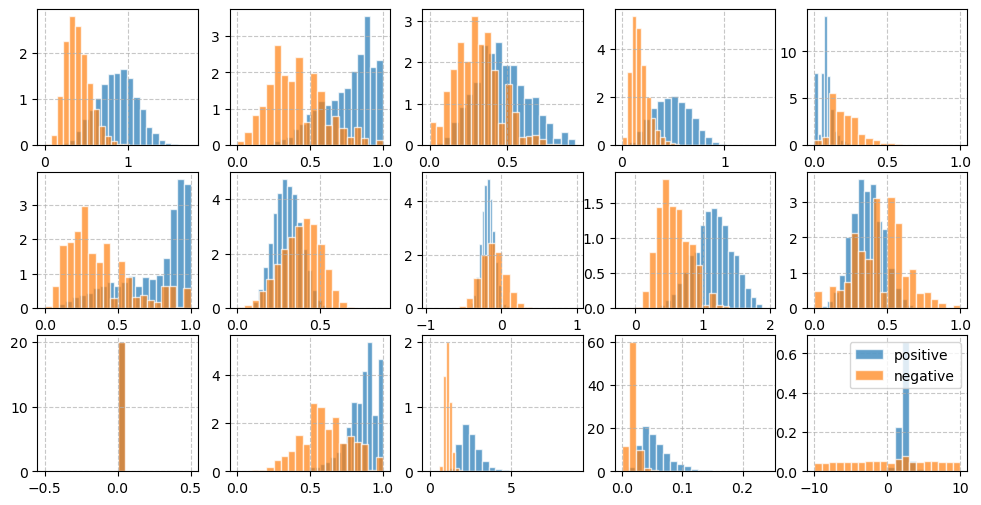

In [261]:
feature_num = 15
pos_featuress = [list() for i in range(feature_num)]
neg_featuress = [list() for i in range(feature_num)]
for modified_seq,features in pp2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==8:
            pos_featuress[i].append(features[i]/(seq_len-1))
        else:
            pos_featuress[i].append(features[i])
for modified_seq,features in np2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==8:
            neg_featuress[i].append(features[i]/(seq_len-1))
        else:
            neg_featuress[i].append(features[i])
print(len(pos_featuress[0]))

row,col = 3,5
fig,axes = plt.subplots(row,col,figsize=(12,6))
feature_names = []
# mass_shift,intensity_sum/total_intensity,new,seq_ratio,0,n_ratio_old,raw_score,error_mean,error_std,conti_num,not_conti_num,intensity_sum/(pepLen-1),n_ratio,c_ratio,fine_score
for i in range(feature_num):
    r,c = int(i/col),i%col
    plot_distribution(axes[r,c], pos_featuress[i], plot_type='density', bins=20, label='positive', save_path=None)
    plot_distribution(axes[r,c], neg_featuress[i], plot_type='density', bins=20, label='negative', save_path=None)
    # axes[r,c].set_title(chr(ord('A')+i))
    axes[r,c].set_ylabel("")
plt.legend()

16504


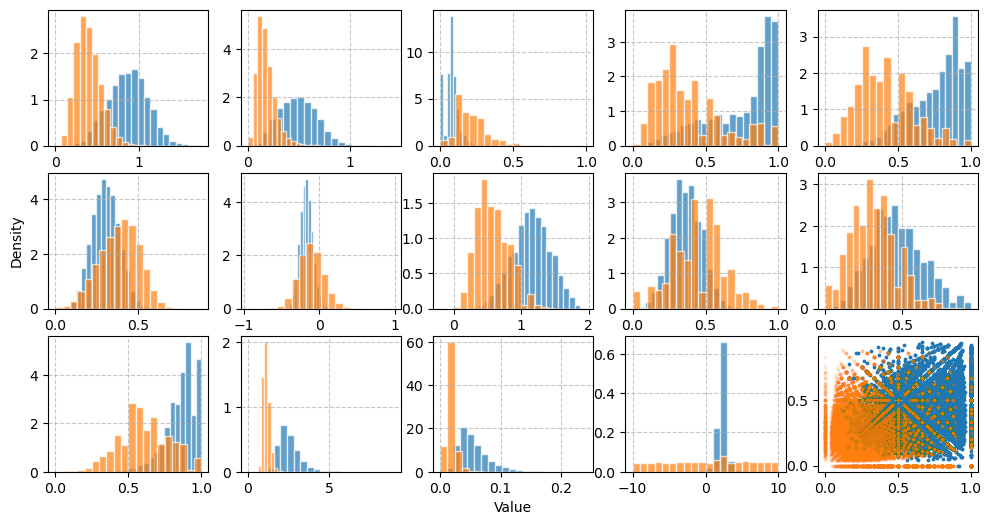

In [70]:
feature_num = 15
pos_featuress = [list() for i in range(feature_num)]
neg_featuress = [list() for i in range(feature_num)]
for modified_seq,features in pp2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==8:
            pos_featuress[i].append(features[i]/(seq_len-1))
        else:
            pos_featuress[i].append(features[i])
for modified_seq,features in np2features.items():
    seq_len = len(modified_seq.split("\t")[0])
    for i in range(feature_num):
        if i==0 or i==8:
            neg_featuress[i].append(features[i]/(seq_len-1))
        else:
            neg_featuress[i].append(features[i])
pos_featuress = np.array(pos_featuress)
neg_featuress = np.array(neg_featuress)
print(len(pos_featuress[0]))

row,col = 3,5
fig,axes = plt.subplots(row,col,figsize=(12,6))
feature_names = []
# mass_shift,intensity_sum/total_intensity,new,seq_ratio,0,n_ratio_old,raw_score/(seq_len-1),error_mean,error_std,max_conti_ratio,max_not_conti_ratio,intensity_sum/(pepLen-1),n_ratio,c_ratio,fine_score/(seq_len-1)
# fine_score/(seq_len-1)
plot_distribution(axes[0,0], pos_featuress[0], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,0], neg_featuress[0], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,0].set_ylabel("")
# intensity_sum/(pepLen-1)
plot_distribution(axes[0,1], pos_featuress[3], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,1], neg_featuress[3], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,1].set_ylabel("")
# max_not_conti_ratio
plot_distribution(axes[0,2], pos_featuress[4], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,2], neg_featuress[4], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,2].set_ylabel("")
# max_conti_ratio
plot_distribution(axes[0,3], pos_featuress[5], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,3], neg_featuress[5], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,3].set_ylabel("")
# error_std
plot_distribution(axes[1,0], pos_featuress[6], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,0], neg_featuress[6], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,0].set_ylabel("Density")
# error_mean
plot_distribution(axes[1,1], pos_featuress[7], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,1], neg_featuress[7], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,1].set_ylabel("")
# raw_score/(seq_len-1)
plot_distribution(axes[1,2], pos_featuress[8], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,2], neg_featuress[8], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,2].set_ylabel("")
# n_ratio_old
plot_distribution(axes[1,3], pos_featuress[9], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,3], neg_featuress[9], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,3].set_ylabel("")
# seq_ratio
plot_distribution(axes[2,0], pos_featuress[11], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,0], neg_featuress[11], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,0].set_ylabel("")
# new
plot_distribution(axes[2,1], pos_featuress[12], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,1], neg_featuress[12], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,1].set_ylabel("")
# intensity_sum/total_intensity
plot_distribution(axes[2,2], pos_featuress[13], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,2], neg_featuress[13], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,2].set_ylabel("")
axes[2,2].set_xlabel("Value")
# mass_shift
plot_distribution(axes[2,3], pos_featuress[14], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[2,3], neg_featuress[14], plot_type='density', bins=20, label='negative', save_path=None)
axes[2,3].set_ylabel("")
# c_ratio
plot_distribution(axes[0,4], pos_featuress[1], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[0,4], neg_featuress[1], plot_type='density', bins=20, label='negative', save_path=None)
axes[0,4].set_ylabel("")
# n_ratio
plot_distribution(axes[1,4], pos_featuress[2], plot_type='density', bins=20, label='positive', save_path=None)
plot_distribution(axes[1,4], neg_featuress[2], plot_type='density', bins=20, label='negative', save_path=None)
axes[1,4].set_ylabel("")
# n_ratio,c_ratio: scatter
axes[2,4].scatter(pos_featuress[1],pos_featuress[2],label='positive',s=3)
axes[2,4].scatter(neg_featuress[1],neg_featuress[2],label='negative',s=3,alpha=0.03)
# axes[2,4].legend()

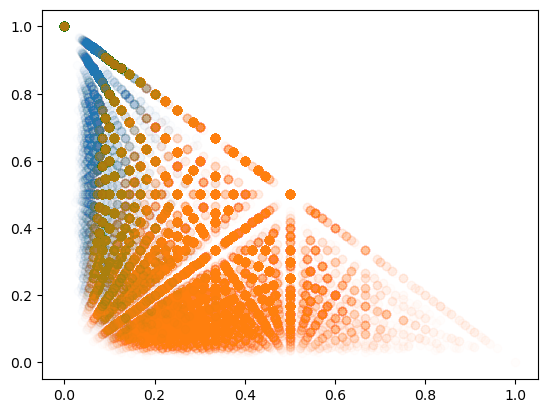

In [56]:
# plt.scatter(pos_featuress[13],[1 for i in range(len(pos_featuress[3]))],label='positive')
# plt.scatter(neg_featuress[13],[1 for i in range(len(neg_featuress[3]))],label='negative',alpha=0.1)


plt.scatter(pos_featuress[4],pos_featuress[5],label='positive',alpha=0.01)
plt.scatter(neg_featuress[4],neg_featuress[5],label='negative',alpha=0.01)
plt.show()

In [229]:
neg_featuress[1][0],neg_featuress[1][0]
pos_featuress[2][0],pos_featuress[2][0]
neg_featuress[9][0],neg_featuress[9][0]
pos_featuress[11][0],pos_featuress[11][0]

(0.0, 0.0)

In [233]:
pos_featuress[1][0],pos_featuress[2][0],pos_featuress[9][0],pos_featuress[11][0]
# neg_featuress[1][0],neg_featuress[2][0],neg_featuress[9][0],neg_featuress[11][0]

(0.642857, 0.47619, 0.464286, 0.952381)